# **Step 1: Import Required Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Step 2: Load the Cleaned Dataset**

In [ ]:
df = pd.read_csv("/content/ckd_cleaned.csv")

# **Step 3: View the Dataset**

In [ ]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,121.0,...,38,6000,5.2,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,5.2,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


# **Step 4: Check Dataset Information**



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    object 
 6   pc              400 non-null    object 
 7   pcc             400 non-null    object 
 8   ba              400 non-null    object 
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             400 non-null    object 
 16  wc              400 non-null    object 
 17  rc              400 non-null    obj

# **Step 5: Summary Statistics**

In [ ]:
df.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000
mean,51.562500,76.575000,1.017712,0.90000,0.395000,145.062500,56.693000,2.997125,137.631250,4.577250,12.54250
std,16.982996,13.489785,0.005434,1.31313,1.040038,75.260774,49.395258,5.628886,9.206332,2.821357,2.71649
min,2.000000,50.000000,1.005000,0.00000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.10000
25%,42.000000,70.000000,1.015000,0.00000,0.000000,101.000000,27.000000,0.900000,135.000000,4.000000,10.87500
50%,55.000000,80.000000,1.020000,0.00000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.65000
75%,64.000000,80.000000,1.020000,2.00000,0.000000,150.000000,61.750000,2.725000,141.000000,4.800000,14.62500
max,90.000000,180.000000,1.025000,5.00000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.80000


# **Biomarker Analysis**

# **Step 6: Age Distribution**

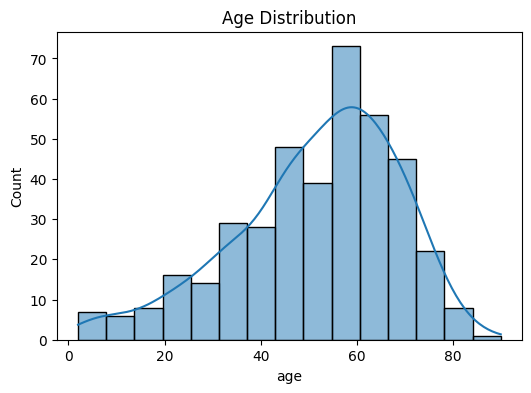

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

# **Step 7: Blood Pressure Distribution**

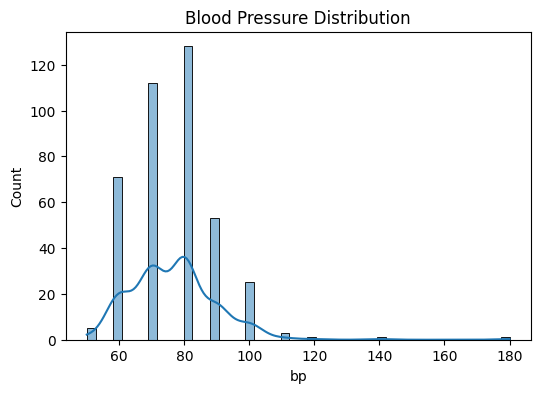

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['bp'], kde=True)
plt.title("Blood Pressure Distribution")
plt.show()

# **Step 8: Blood Glucose Distribution**

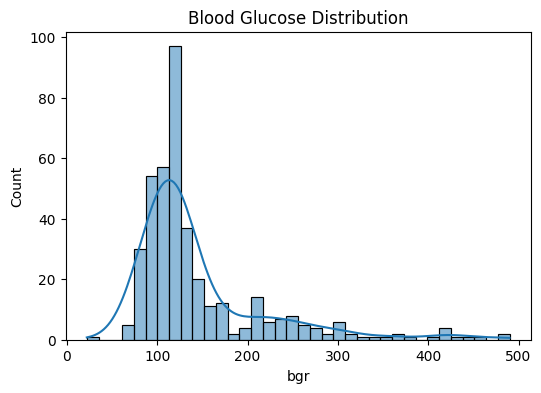

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['bgr'], kde=True)
plt.title("Blood Glucose Distribution")
plt.show()

# **Step 9: Hemoglobin Distribution**

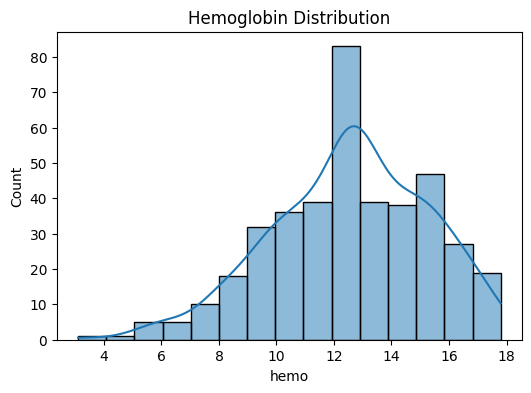

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['hemo'], kde=True)
plt.title("Hemoglobin Distribution")
plt.show()

# **Step 10: Compare Age by CKD Status**

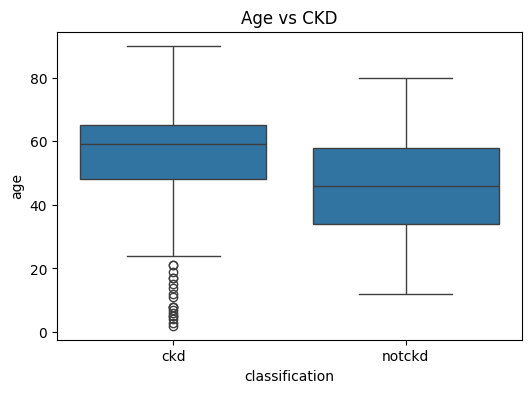

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='classification', y='age', data=df)
plt.title("Age vs CKD")
plt.show()

# **Step 11: Compare Blood Pressure by CKD Status**

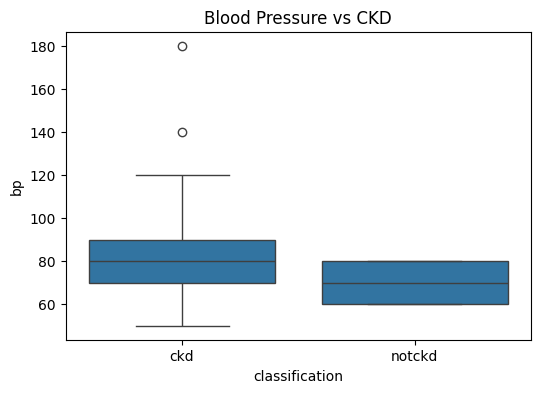

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='classification', y='bp', data=df)
plt.title("Blood Pressure vs CKD")
plt.show()

# **Step 12: Correlation Heatmap**

In [ ]:
df_numeric = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_numeric.select_dtypes(include='object').columns:
    df_numeric[col] = le.fit_transform(df_numeric[col].astype(str))

# Now generate the heatmap.

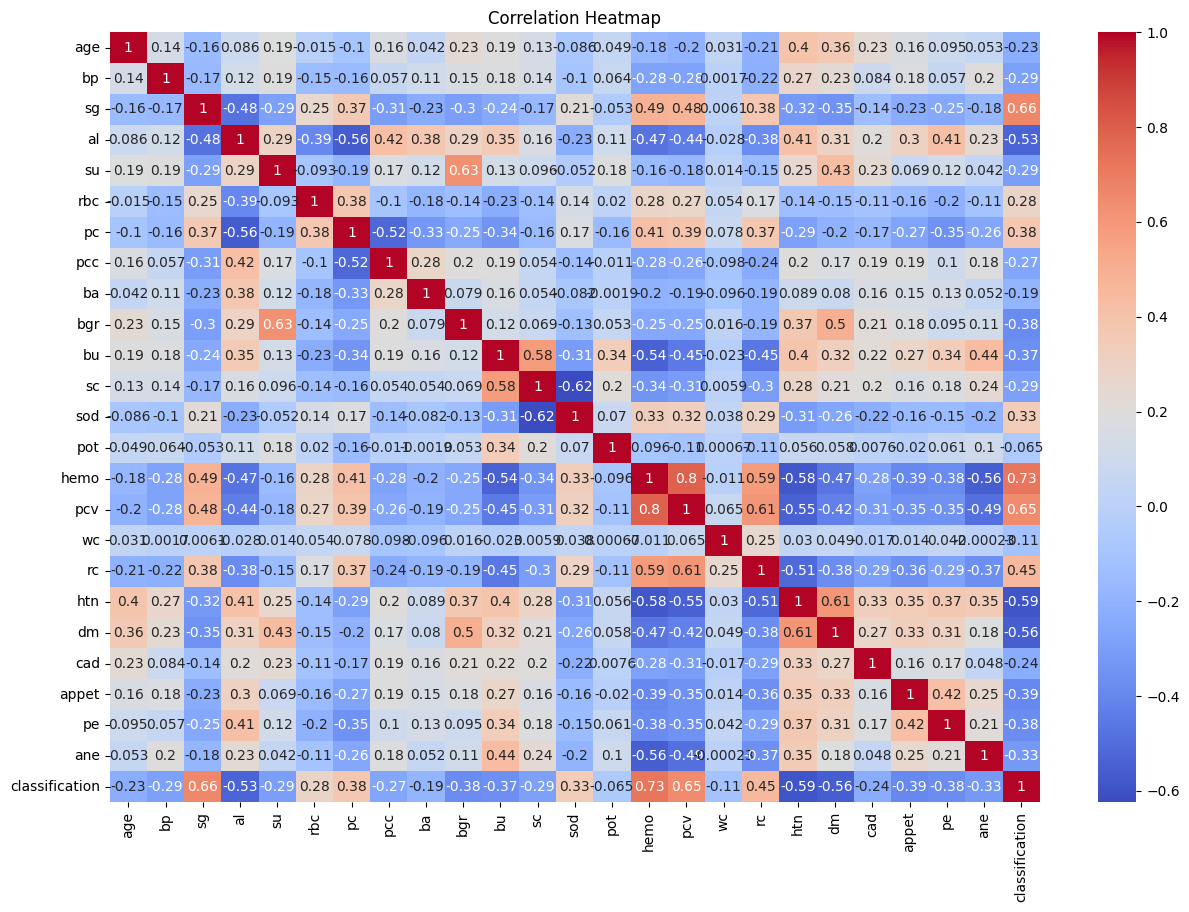

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Step 13: Identify Highly Correlated Features**

In [ ]:
corr = df_numeric.corr()

corr['classification'].sort_values(ascending=False)

,classification
classification,1.000000
hemo,0.726368
sg,0.659504
pcv,0.646883
rc,0.449406
pc,0.375154
sod,0.334900
rbc,0.282642
pot,-0.065218
wc,-0.112155
